In [7]:
import hicona
import cooler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import IncrementalPCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats
import pybedtools
import os

### 0. Workflow

1. Generate **EIS** array: n rows * 5 columns (cell cycle phases)
2. Generate **compartment** array: n rows * 5 mean columns + 5 std columns
3. Generate the combined **array**
4. **KNN clustering**
7. **Plotting of heatmap and validation**

In [3]:
path_cool='cell_cycle_Dekker/results_25kb/'
cools=os.listdir(path_cool)
def retrieve_names(file):
    spl=file.split('_')
    if spl[2].startswith('GSM'):
        condition=spl[3]
        phase=spl[4]
        region=spl[-1]
    else:
        condition=spl[4]
        phase=spl[5]
        region=spl[-1]
    return condition,phase,region

In [ ]:
# deltaGAP1
cools=os.listdir(path_cool)
REGS=['chr8:100000000-120000000','chr14:54000000-80000000','chr17:32000000-52000000','chr7:78000000-105000000','chr6:125000000-145500000','chr7:18500000-38500000','chr8:29500000-59500000','chr14:33500000-55500000','chr17:47500000-73400000']
bins=pd.read_csv('bins/bins_25000.csv')

COND='deltaGAP1'
df_del=[]

for reg in REGS:
    mats=[]
    for PHASE in ['Mito','Telo','Cyto','G1s5h','G1s10h']:
        clrs=[]
        for c in cools:
            if (COND in c)&(reg in c)&(PHASE in c):
                clrs.append(c)
        if len(clrs)==1:
            clr=clrs[0]


        condition,phase,region=retrieve_names(clr)
        if (phase==PHASE) & (condition==COND):
            print(clr)
            table=[x for x in os.listdir(f'{path_cool}{clr}') if x.endswith('pixels')][0]
            pixels=hicona.PixelTable.load(f'{path_cool}{clr}/{table}')
            pix=pixels.get_dataframe(dtype='pandas')
            m=pixels.get_matrix(region=region,value_col='pix_prob')
            mats.append(m)

    n = mats[0].shape[0]
    
    # upper triangle indices (exclude diagonal)
    iu = np.triu_indices(n, k=1)
    # edge coordinates (n_edges, 2): columns are i, j
    edges = np.column_stack(iu)
    phases=['Mito' for x in range(int(edges.shape[0]/5))]+['Telo' for x in range(int(edges.shape[0]/5))]+['Cyto' for x in range(int(edges.shape[0]/5))]+['G1s5h' for x in range(int(edges.shape[0]/5))]+['G1s10h' for x in range(int(edges.shape[0]/5))]
    # build matrix: rows = edges, cols = phases
    W = np.stack([A[iu] for A in mats], axis=1)
    out = np.column_stack([edges, W])
    df=pd.DataFrame(out,columns=['bin1_id','bin2_id','prometa','anatelo','cyto','G1_5h','G1_10h'])
    df['dist']=np.abs(df['bin2_id']-df['bin1_id'])*25
    df['dist']=df['dist'].astype(int)
    df=df[df['dist']>0]
    df['region']=region

    start=bins[(bins['chrom']==reg.split(':')[0])&(bins['start']>=int(reg.split(':')[1].split('-')[0]))].index[0]
    df['bin1_id']=df['bin1_id']+start
    df['bin2_id']=df['bin2_id']+start
    
    df['bin1_id']=df['bin1_id'].astype(int)
    df['bin2_id']=df['bin2_id'].astype(int)
    
    df['bin1_id']=df['bin1_id'].astype(int)
    df['bin2_id']=df['bin2_id'].astype(int)
    
    df['pair']=df['bin1_id'].astype(str)+'-'+df['bin2_id'].astype(str)
    df['pair']=['-'.join(sorted(x.split('-'))) for x in df['pair']]
    df=cooler.annotate(df,bins)
    df_del.append(df)


df_del=pd.concat(df_del,ignore_index=True)



# untreated

cools=os.listdir(path_cool)
REGS=['chr8:100000000-120000000','chr14:54000000-80000000','chr17:32000000-52000000','chr7:78000000-105000000','chr6:125000000-145500000','chr7:18500000-38500000','chr8:29500000-59500000','chr14:33500000-55500000','chr17:47500000-73400000']
bins=pd.read_csv('bins/bins_25000.csv')

COND='ranGAP1'
df_con=[]

for reg in REGS:
    mats=[]
    for PHASE in ['Mito','Telo','Cyto','G1s5h','G1s10h']:
        clrs=[]
        for c in cools:
            if (COND in c)&(reg in c)&(PHASE in c):
                clrs.append(c)
        if len(clrs)==1:
            clr=clrs[0]

        condition,phase,region=retrieve_names(clr)
        if region == 'bis':
            region=reg
        if (phase==PHASE) & (condition==COND):
            print(clr)
            table=[x for x in os.listdir(f'{path_cool}{clr}') if x.endswith('pixels')][0]
            pixels=hicona.PixelTable.load(f'{path_cool}{clr}/{table}')
            pix=pixels.get_dataframe(dtype='pandas')
            m=pixels.get_matrix(region=region,value_col='pix_prob')
            mats.append(m)

    n = mats[0].shape[0]
    
    # upper triangle indices (exclude diagonal)
    iu = np.triu_indices(n, k=1)
    # edge coordinates (n_edges, 2): columns are i, j
    edges = np.column_stack(iu)
    phases=['Mito' for x in range(int(edges.shape[0]/5))]+['Telo' for x in range(int(edges.shape[0]/5))]+['Cyto' for x in range(int(edges.shape[0]/5))]+['G1s5h' for x in range(int(edges.shape[0]/5))]+['G1s10h' for x in range(int(edges.shape[0]/5))]
    # build matrix: rows = edges, cols = phases
    W = np.stack([A[iu] for A in mats], axis=1)
    out = np.column_stack([edges, W])
    df=pd.DataFrame(out,columns=['bin1_id','bin2_id','prometa','anatelo','cyto','G1_5h','G1_10h'])
    #df['phase']=phases
    df['dist']=np.abs(df['bin2_id']-df['bin1_id'])*25
    df['dist']=df['dist'].astype(int)
    df=df[df['dist']>0]
    df['region']=region
    start=bins[(bins['chrom']==reg.split(':')[0])&(bins['start']>=int(reg.split(':')[1].split('-')[0]))].index[0]
    df['bin1_id']=df['bin1_id']+start
    df['bin2_id']=df['bin2_id']+start
    
    df['bin1_id']=df['bin1_id'].astype(int)
    df['bin2_id']=df['bin2_id'].astype(int)
    
    df['pair']=df['bin1_id'].astype(str)+'-'+df['bin2_id'].astype(str)
    df['pair']=['-'.join(sorted(x.split('-'))) for x in df['pair']]
    df=cooler.annotate(df,bins)
    df_con.append(df)

df_con=pd.concat(df_con,ignore_index=True)

### 1) EIS array

In [ ]:
df_EIS_del=df_del[['pair','prometa' 	,'anatelo' 	,'cyto' 	,'G1_5h' 	,'G1_10h']]
df_EIS_ran=df_con[['pair','prometa' 	,'anatelo' 	,'cyto' 	,'G1_5h' 	,'G1_10h']]
array_EIS_ran=df_EIS_ran[['prometa' 	,'anatelo' 	,'cyto' 	,'G1_5h' 	,'G1_10h']].to_numpy()
array_EIS_del=df_EIS_del[['prometa' 	,'anatelo' 	,'cyto' 	,'G1_5h' 	,'G1_10h']].to_numpy()

### 2) Comps array

In [ ]:
comp_phases=['Prometa','Anatelo','Cyto','G1s5h','G1s10h']


df=df_del.copy()
cond='delta'
for i in range(len(comp_phases)):
    cphase=comp_phases[i]
    print(phase)
    df['comp_rank1']=df[f'{cond}GAP1_{cphase}_continuous_rank1']
    df['comp_rank2']=df[f'{cond}GAP1_{cphase}_continuous_rank2']
    df[f'{cphase}_std']=df[['comp_rank1','comp_rank2']].std(axis=1)
    df[f'{cphase}_mean']=df[['comp_rank1','comp_rank2']].mean(axis=1)
df_COMP_del=df[['pair','prometa' 	,'anatelo' 	,'cyto' 	,'G1_5h' 	,'G1_10h']+[x for x in df.columns if '_mean' in x]+[x for x in df.columns if '_std' in x]]


df_comp=[]
heat_ran=[]
df=df_con.copy()
cond='ran'
for i in range(len(comp_phases)):
    cphase=comp_phases[i]
    print(phase)
    df['comp_rank1']=df[f'{cond}GAP1_{cphase}_continuous_rank1']
    df['comp_rank2']=df[f'{cond}GAP1_{cphase}_continuous_rank2']
    df[f'{cphase}_std']=df[['comp_rank1','comp_rank2']].std(axis=1)
    df[f'{cphase}_mean']=df[['comp_rank1','comp_rank2']].mean(axis=1)
df_COMP_ran=df[['pair','prometa' 	,'anatelo' 	,'cyto' 	,'G1_5h' 	,'G1_10h']+[x for x in df.columns if '_mean' in x]+[x for x in df.columns if '_std' in x]]
array_COMP_ran=df_COMP_ran[[x for x in df_COMP_ran.columns if '_mean' in x]+[x for x in df_COMP_ran.columns if '_std' in x]].to_numpy()
array_COMP_del=df_COMP_del[[x for x in df_COMP_del.columns if '_mean' in x]+[x for x in df_COMP_del.columns if '_std' in x]].to_numpy()

### 3) Combined array

In [ ]:
df_ran=df_COMP_ran[['pair','prometa' 	,'anatelo' 	,'cyto' 	,'G1_5h' 	,'G1_10h']+[x for x in df_COMP_ran.columns if '_mean' in x]+[x for x in df_COMP_ran.columns if '_std' in x]]
df_del=df_COMP_del[['pair','prometa' 	,'anatelo' 	,'cyto' 	,'G1_5h' 	,'G1_10h']+[x for x in df_COMP_del.columns if '_mean' in x]+[x for x in df_COMP_del.columns if '_std' in x]]

### 4) KNN clustering

In [27]:
def pca(df):
    cols=df.columns[:-1].tolist()
    array=df[cols].fillna(0).to_numpy()
    ipca = IncrementalPCA(n_components=5,)

    X_reduced = ipca.fit_transform(array)
    print('pca computed')
    return X_reduced


def kmeans(pca_value,n_cl,state):
    kmeans = KMeans(n_clusters=n_cl,random_state=state)
    labels = kmeans.fit_predict(pca_value)
    print('kmeans computed')
    return labels

In [28]:
pca_ran=pca(df_ran)
pca_del=pca(df_del)

pca computed
pca computed


kmeans computed
kmeans computed


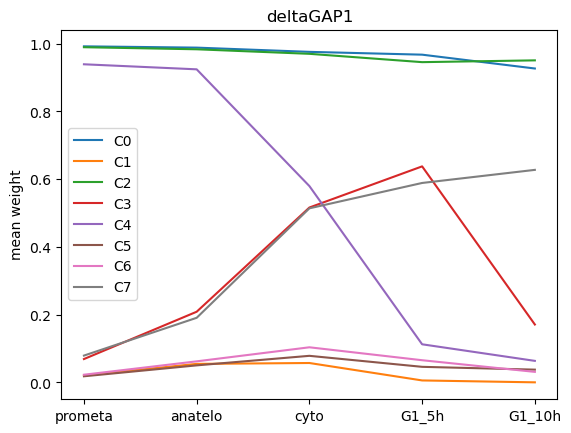

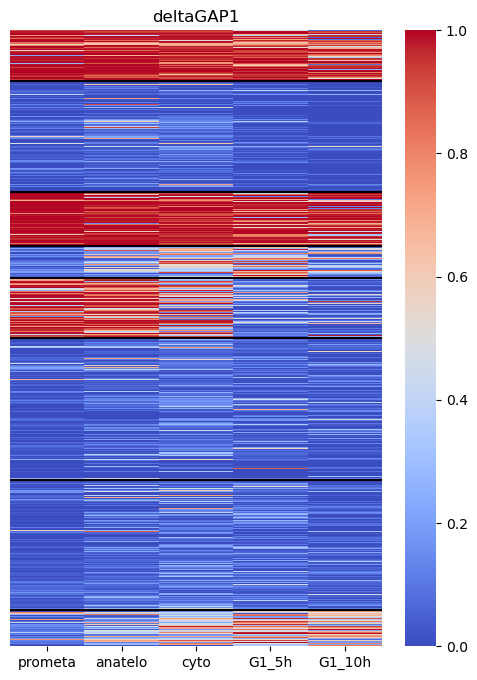

In [42]:
cln=8
rnd_state=3
kmeans_ran = kmeans(pca_ran,cln,rnd_state)
kmeans_del = kmeans(pca_del,cln,rnd_state)

df=df_del.copy()
phases=['prometa' 	,'anatelo' 	,'cyto' 	,'G1_5h' 	,'G1_10h']
df["cluster"]  =  kmeans_del
Xp=df[phases].values
df=df.fillna(0)


for c in sorted(df.cluster.unique()):
    mean_profile = df[df.cluster==c][phases].median()
    plt.plot(phases, mean_profile, label=f"C{c}")


plt.legend()
plt.ylabel("mean weight")
plt.title('deltaGAP1')
plt.show()


df_sorted = df.sort_values("cluster")

X_sorted = df_sorted[phases].to_numpy()
clusters_sorted = df_sorted["cluster"].to_numpy()

boundaries = np.where(np.diff(clusters_sorted) != 0)[0] + 1

plt.figure(figsize=(6,8))
ax = sns.heatmap(pd.DataFrame(X_sorted,columns=phases), cmap="coolwarm", center=0.5, yticklabels=False)
for b in boundaries:
    ax.hlines(b, *ax.get_xlim(), colors="black", linewidth=1.5)
# plt.savefig(f'{out_path}_heatmap.png',dpi=250)
plt.title('deltaGAP1')
plt.show()

Text(0.5, 1.0, 'clusters interaction distance deltaGAP1')

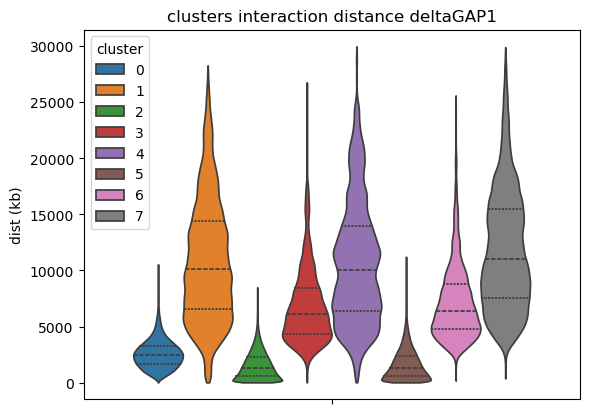

In [45]:
df=df_del.copy()

df['dist (kb)']=[np.abs(int(x.split('-')[0])-int(x.split('-')[1]))*25 for x in df.index]
sns.violinplot(df,hue='cluster',y='dist (kb)',palette='tab10',inner='quart',cut=0)
plt.title('clusters interaction distance deltaGAP1')

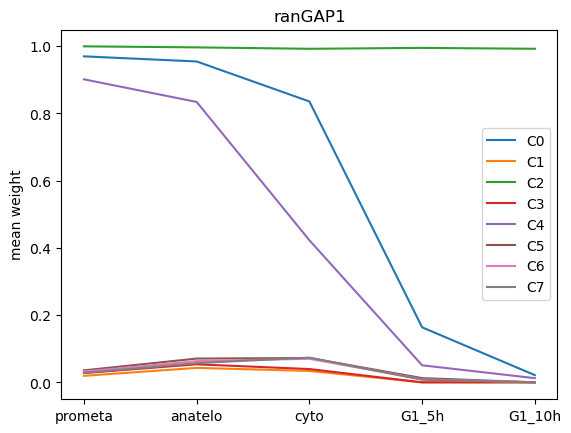

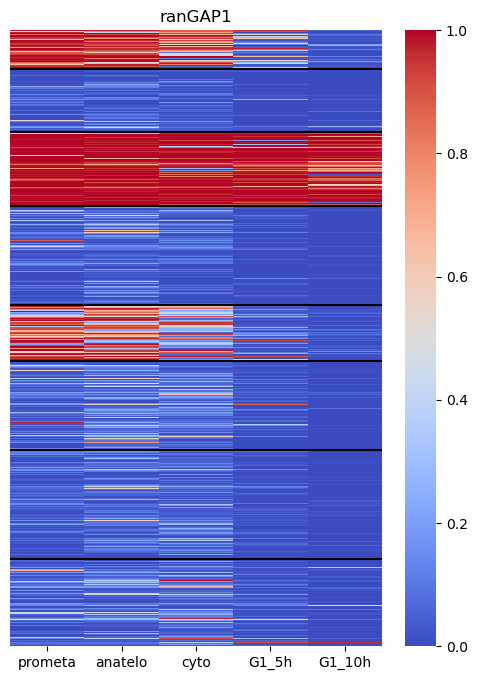

In [43]:
df=df_ran.copy()
phases=['prometa' 	,'anatelo' 	,'cyto' 	,'G1_5h' 	,'G1_10h']
df["cluster"]  =  kmeans_ran

Xp=df[phases].values
df=df.fillna(0)


for c in sorted(df.cluster.unique()):
    mean_profile = df[df.cluster==c][phases].median()
    plt.plot(phases, mean_profile, label=f"C{c}")


plt.legend()
plt.ylabel("mean weight")
plt.title('ranGAP1')
plt.show()

df_sorted = df.sort_values("cluster")

X_sorted = df_sorted[phases].to_numpy()
clusters_sorted = df_sorted["cluster"].to_numpy()

boundaries = np.where(np.diff(clusters_sorted) != 0)[0] + 1

plt.figure(figsize=(6,8))
ax = sns.heatmap(pd.DataFrame(X_sorted,columns=phases), cmap="coolwarm", center=0.5, yticklabels=False)
for b in boundaries:
    ax.hlines(b, *ax.get_xlim(), colors="black", linewidth=1.5)
plt.title('ranGAP1')
plt.show()

Text(0.5, 1.0, 'clusters interaction distance untreated')

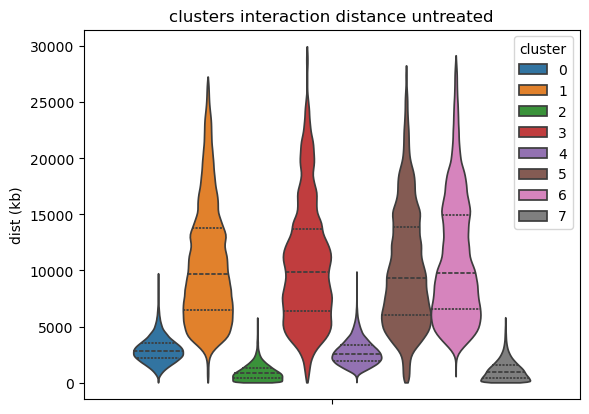

In [46]:
df=df_ran.copy()

df['dist (kb)']=[np.abs(int(x.split('-')[0])-int(x.split('-')[1]))*25 for x in df.index]
sns.violinplot(df,hue='cluster',y='dist (kb)',palette='tab10',inner='quart',cut=0)
plt.title('clusters interaction distance untreated')

### 5) Plotting of heatmap and validation

In [47]:
bins=pd.read_csv('bins/bins2_25000.csv',index_col=0)

In [48]:
df_del['bin1_id']=[int(x.split('-')[0]) for x in df_del.index]
df_del['bin2_id']=[int(x.split('-')[1]) for x in df_del.index]
df_ran['bin1_id']=[int(x.split('-')[0]) for x in df_ran.index]
df_ran['bin2_id']=[int(x.split('-')[1]) for x in df_ran.index]


anno_del=cooler.annotate(df_del,bins[['G1con_CTCF',
       'G1con_H3K27ac', 'G1con_H3K27me3', 'G1con_H3K4me3', 'G1del_CTCF',
       'G1del_H3K27ac', 'G1del_H3K27me3', 'G1del_H3K4me3', 'prometa_CTCF',
       'prometa_H3K27ac', 'prometa_H3K27me3', 'prometa_H3K4me3']])
anno_ran=cooler.annotate(df_ran,bins[['G1con_CTCF',
       'G1con_H3K27ac', 'G1con_H3K27me3', 'G1con_H3K4me3', 'G1del_CTCF',
       'G1del_H3K27ac', 'G1del_H3K27me3', 'G1del_H3K4me3', 'prometa_CTCF',
       'prometa_H3K27ac', 'prometa_H3K27me3', 'prometa_H3K4me3']])

Text(0.5, 1.0, 'deltaGAP1 homotypic interactions enrichment')

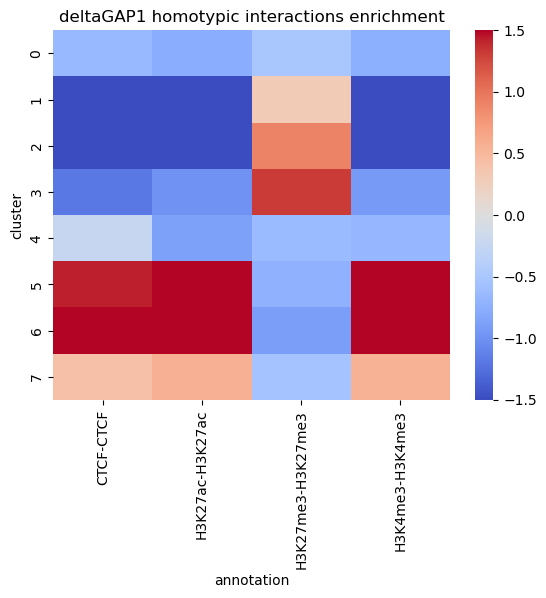

In [57]:
df=anno_del.copy()
marks=['CTCF','H3K27ac','H3K4me3','H3K27me3']

cond=''
phase='G1del'
clusters=sorted(list(set(df['cluster'])))
pseudo=1e-10


CLUSTERS=[]
PAIRS=[]
LOG2s=[]
for cl in clusters:
    pair=[]
    for m1 in marks:
        for m2 in marks:
            p='-'.join(sorted([m1,m2]))
            if p in pair:
                continue
            else:
                pair.append(p)
                dff=df[df['cluster']==cl]
                if m1==m2:
                    dff_m=(dff[(dff[f'{phase}{cond}_{m1}1']>0)&(dff[f'{phase}{cond}_{m1}2']>0)].shape[0]+pseudo)/(dff.shape[0]+pseudo)
                    df_m=(df[(df[f'{phase}{cond}_{m1}1']>0)&(df[f'{phase}{cond}_{m1}2']>0)].shape[0]+pseudo)/(df.shape[0]+pseudo)
                    log2FC=np.log2(dff_m/df_m)

                    CLUSTERS.append(cl)
                    PAIRS.append(p)
                    LOG2s.append(log2FC)

df_final=pd.DataFrame([CLUSTERS,PAIRS,LOG2s],index=['cluster','annotation','log2FC']).T
heat_del=pd.pivot_table(df_final,values='log2FC',index='cluster',columns='annotation')
sns.heatmap(heat_del.astype(float),cmap='coolwarm',annot=False,vmin=-1.5,vmax=1.5)
plt.title('deltaGAP1 homotypic interactions enrichment')

Text(0.5, 1.0, 'untreated homotypic interactions enrichment')

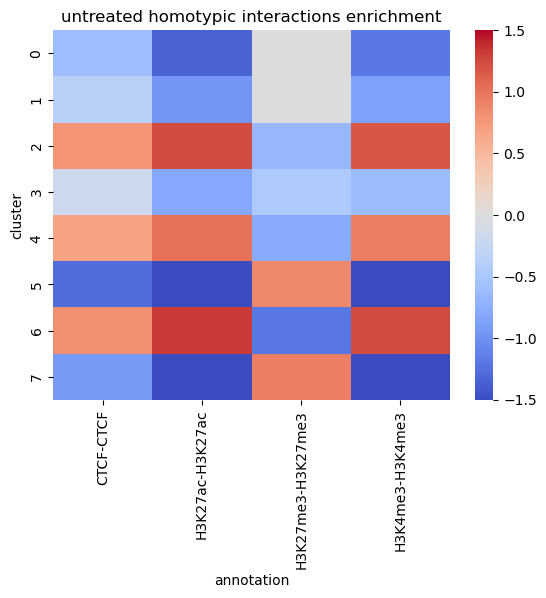

In [58]:
df=anno_ran.copy()
marks=['CTCF','H3K27ac','H3K4me3','H3K27me3']

cond=''
phase='G1con'
clusters=sorted(list(set(df['cluster'])))
pseudo=1e-10


CLUSTERS=[]
PAIRS=[]
LOG2s=[]
for cl in clusters:
    pair=[]
    for m1 in marks:
        for m2 in marks:
            p='-'.join(sorted([m1,m2]))
            if p in pair:
                continue
            else:
                pair.append(p)
                dff=df[df['cluster']==cl]
                if m1==m2:
                    dff_m=(dff[(dff[f'{phase}{cond}_{m1}1']>0)&(dff[f'{phase}{cond}_{m1}2']>0)].shape[0]+pseudo)/(dff.shape[0]+pseudo)
                    df_m=(df[(df[f'{phase}{cond}_{m1}1']>0)&(df[f'{phase}{cond}_{m1}2']>0)].shape[0]+pseudo)/(df.shape[0]+pseudo)
                    log2FC=np.log2(dff_m/df_m)

                    CLUSTERS.append(cl)
                    PAIRS.append(p)
                    LOG2s.append(log2FC)

df_final=pd.DataFrame([CLUSTERS,PAIRS,LOG2s],index=['cluster','annotation','log2FC']).T
heat_con=pd.pivot_table(df_final,values='log2FC',index='cluster',columns='annotation')
sns.heatmap(heat_con.astype(float),cmap='coolwarm',annot=False,vmin=-1.5,vmax=1.5)
plt.title('untreated homotypic interactions enrichment')